In [1]:
import tensorflow_federated as tff

2026-03-31 16:58:00.494996: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-31 16:58:00.891240: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-31 16:58:00.891270: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-31 16:58:00.893731: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-31 16:58:01.107933: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-31 16:58:01.109637: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

In [2]:
emnist_train, emnist_test = tff.simulation.datasets.emnist.load_data()

2026-03-31 16:58:29.659654: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [3]:
len(emnist_train.client_ids)

3383

In [4]:
emnist_train.element_type_structure

OrderedDict([('label', TensorSpec(shape=(), dtype=tf.int32, name=None)),
             ('pixels',
              TensorSpec(shape=(28, 28), dtype=tf.float32, name=None))])

In [5]:
# create_tf_dataset_for_client takes in a client id and creates the associated dataset
example_dataset = emnist_train.create_tf_dataset_for_client(emnist_train.client_ids[69])

In [6]:
example_element = next(iter(example_dataset))

In [7]:
type(example_element)

collections.OrderedDict

In [8]:
example_element.keys()

odict_keys(['label', 'pixels'])

In [9]:
example_element["label"].numpy()

1

In [10]:
type(example_element["label"])

tensorflow.python.framework.ops.EagerTensor

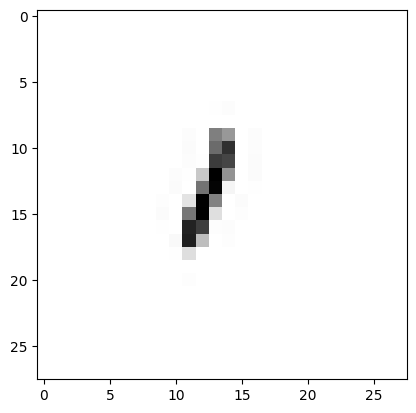

In [12]:
from matplotlib import pyplot as plt
plt.imshow(example_element['pixels'].numpy(), cmap='gray', aspect='equal')
plt.grid(False)
_ = plt.show()

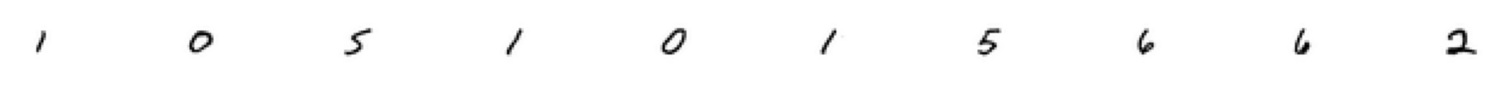

In [13]:
## Example MNIST digits for one client
figure = plt.figure(figsize=(20, 4))
j = 0

for example in example_dataset.take(10):
  plt.subplot(4, 10, j+1)
  plt.imshow(example['pixels'].numpy(), cmap='gray', aspect='equal')
  plt.axis('off')
  j += 1

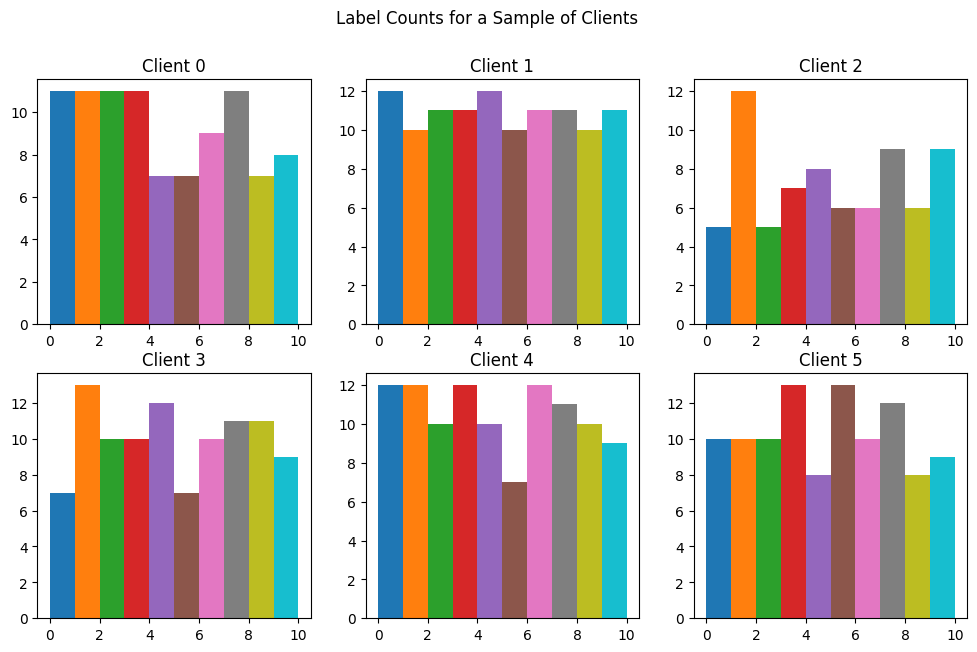

In [15]:
import collections
# Number of examples per layer for a sample of clients
f = plt.figure(figsize=(12, 7))
f.suptitle('Label Counts for a Sample of Clients')
for i in range(6):
  client_dataset = emnist_train.create_tf_dataset_for_client(
      emnist_train.client_ids[i])
  plot_data = collections.defaultdict(list)
  for example in client_dataset:
    # Append counts individually per label to make plots
    # more colorful instead of one color per plot.
    label = example['label'].numpy()
    plot_data[label].append(label)
  plt.subplot(2, 3, i+1)
  plt.title('Client {}'.format(i))
  for j in range(10):
    plt.hist(
        plot_data[j],
        density=False,
        bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

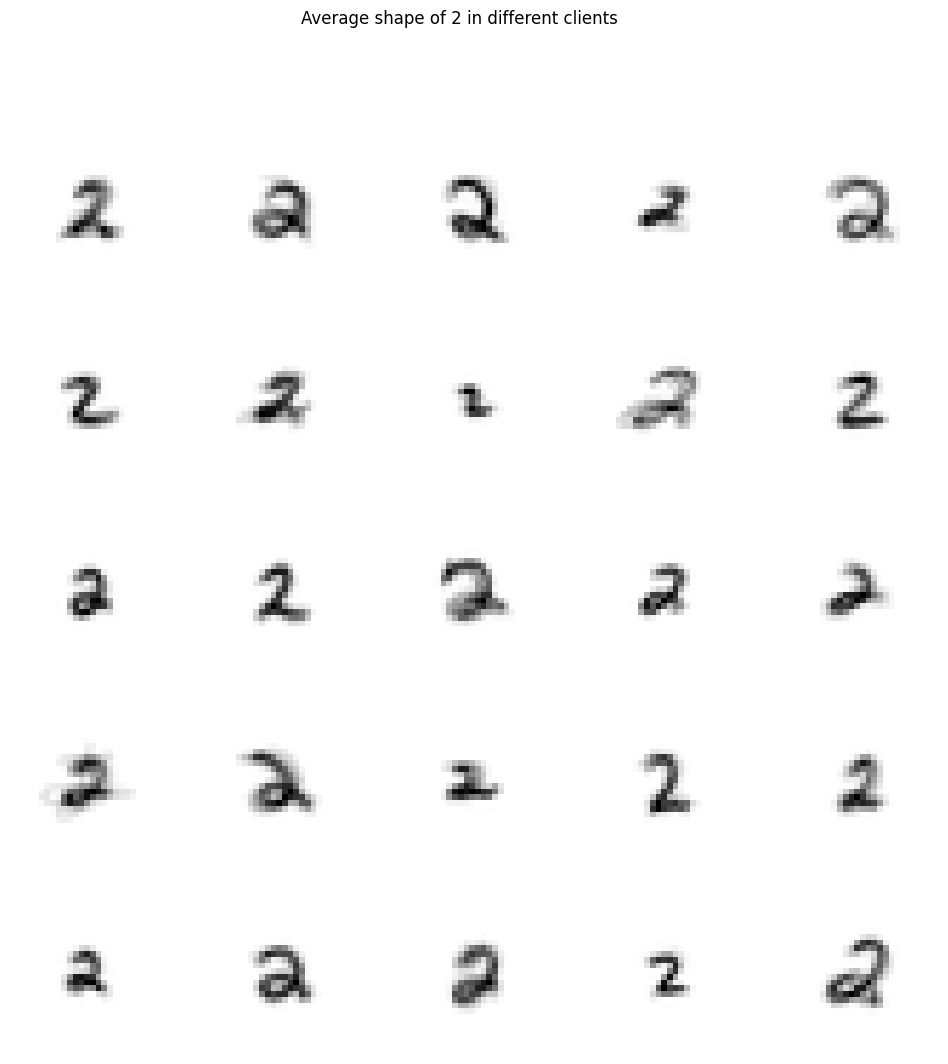

In [22]:
import numpy as np
NUM_CLIENTS = 25
sample_clients = np.random.choice(emnist_train.client_ids, NUM_CLIENTS)
plot_data = []
for k, i in enumerate(sample_clients):
  client_dataset = emnist_train.create_tf_dataset_for_client(i)
  tmp = []
  for example in client_dataset:
    # Only take 2
    if example["label"].numpy() == 2:
        tmp.append(example['pixels'].numpy())
  mean_img = np.mean(tmp, 0)
  plot_data.append(mean_img)

f, axs = plt.subplots(5, 5, figsize=(12, 12))
axs = axs.flatten()
f.suptitle("Average shape of 2 in different clients")
for img, ax in zip(plot_data, axs):
    ax.imshow(img.reshape((28, 28)), cmap="gray")
    ax.axis("off")
plt.show()